# 01 — Análise Exploratória dos Dados

Este notebook realiza a análise exploratória da base consolidada na camada Silver do projeto Retail Demand Forecasting Pipeline.

Objetivos:
- compreender o comportamento das vendas ao longo do tempo;
- identificar padrões de sazonalidade;
- analisar diferenças entre lojas e famílias de produtos;
- investigar o efeito de promoções e feriados sobre as vendas;
- avaliar valores ausentes, zeros e possíveis outliers;
- gerar hipóteses para a etapa de feature engineering e forecasting.

In [1]:
# Importando bibliotecas e carregando a base consolidada da camada Silver

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
SILVER_PATH = PROJECT_ROOT / "data" / "silver" / "sales_enriched.parquet"

df = pd.read_parquet(SILVER_PATH)

df.shape

(3000888, 15)

In [2]:
# Configurando a exibição de números decimais sem notação científica

pd.options.display.float_format = "{:,.2f}".format

In [3]:
# Verificando tipos de dados e valores ausentes da base consolidada

summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(),
    }
)

summary

,dtype,missing,missing_pct,unique
id,int64,0,0.00,3000888
date,datetime64[ns],0,0.00,1684
store_nbr,int64,0,0.00,54
family,object,0,0.00,33
sales,float64,0,0.00,379610
onpromotion,int64,0,0.00,362
city,object,0,0.00,22
state,object,0,0.00,16
type,object,0,0.00,5
cluster,int64,0,0.00,17


In [4]:
# Analisando estatísticas descritivas da variável de vendas

df["sales"].describe()

count   3,000,888.00
mean          357.78
std         1,102.00
min             0.00
25%             0.00
50%            11.00
75%           195.85
max       124,717.00
Name: sales, dtype: float64

In [5]:
# Verificando a proporção de registros com vendas iguais a zero

zero_sales = (df["sales"] == 0).sum()
zero_sales_pct = (df["sales"] == 0).mean() * 100

print(f"Registros com sales = 0: {zero_sales:,}")
print(f"Percentual de sales = 0: {zero_sales_pct:.2f}%")

Registros com sales = 0: 939,130
Percentual de sales = 0: 31.30%


In [6]:
# Analisando a proporção de vendas iguais a zero por família de produto

zero_sales_by_family = (
    df.assign(is_zero=df["sales"].eq(0))
    .groupby("family")["is_zero"]
    .agg(["mean", "sum", "count"])
    .sort_values("mean", ascending=False)
)

zero_sales_by_family["zero_pct"] = (zero_sales_by_family["mean"] * 100).round(2)

zero_sales_by_family[["zero_pct", "sum", "count"]].head(15)

,zero_pct,sum,count
family,,,
BOOKS,96.96,88167,90936
BABY CARE,94.13,85599,90936
SCHOOL AND OFFICE SUPPLIES,74.08,67368,90936
HOME APPLIANCES,73.52,66854,90936
LADIESWEAR,59.85,54422,90936
MAGAZINES,56.54,51414,90936
PET SUPPLIES,54.62,49665,90936
HARDWARE,47.86,43524,90936
LAWN AND GARDEN,46.78,42544,90936


In [7]:
# Verificando em quantas lojas cada família apresentou vendas positivas

active_stores_by_family = (
    df.loc[df["sales"] > 0].groupby("family")["store_nbr"].nunique().sort_values()
)

active_stores_by_family.head(15)

family
BOOKS              26
BABY CARE          42
LADIESWEAR         44
LAWN AND GARDEN    51
BEVERAGES          54
BREAD/BAKERY       54
BEAUTY             54
AUTOMOTIVE         54
DAIRY              54
DELI               54
EGGS               54
FROZEN FOODS       54
GROCERY I          54
GROCERY II         54
CELEBRATION        54
Name: store_nbr, dtype: int64

In [8]:
# Identificando combinações de loja e família com pelo menos uma venda positiva

active_store_family = df.loc[df["sales"] > 0, ["store_nbr", "family"]].drop_duplicates()

# Mantendo apenas combinações ativas de loja e família

df_active = df.merge(
    active_store_family,
    on=["store_nbr", "family"],
    how="inner",
)

# Recalculando a proporção de vendas iguais a zero por família

zero_sales_active = (
    df_active.assign(is_zero=df_active["sales"].eq(0))
    .groupby("family")["is_zero"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

zero_sales_active.head(15)

family
BOOKS                        93.68
BABY CARE                    92.45
SCHOOL AND OFFICE SUPPLIES   74.08
HOME APPLIANCES              73.52
MAGAZINES                    56.54
PET SUPPLIES                 54.62
LADIESWEAR                   50.72
HARDWARE                     47.86
PLAYERS AND ELECTRONICS      44.89
LAWN AND GARDEN              43.65
CELEBRATION                  43.63
HOME CARE                    40.91
HOME AND KITCHEN II          34.71
HOME AND KITCHEN I           34.65
PRODUCE                      28.36
Name: is_zero, dtype: float64

In [9]:
# Identificando a primeira data com venda positiva por família

first_sale_by_family = (
    df.loc[df["sales"] > 0].groupby("family")["date"].min().sort_values(ascending=False)
)

first_sale_by_family.head(15)

family
BOOKS                        2016-10-08
BABY CARE                    2014-03-01
SCHOOL AND OFFICE SUPPLIES   2014-01-02
LADIESWEAR                   2014-01-02
HOME AND KITCHEN II          2014-01-01
PLAYERS AND ELECTRONICS      2014-01-01
CELEBRATION                  2014-01-01
PET SUPPLIES                 2014-01-01
MAGAZINES                    2014-01-01
HOME CARE                    2014-01-01
HOME AND KITCHEN I           2014-01-01
PRODUCE                      2013-03-16
HARDWARE                     2013-01-02
HOME APPLIANCES              2013-01-02
AUTOMOTIVE                   2013-01-02
Name: date, dtype: datetime64[ns]

In [10]:
# Agrupando as vendas por família e por mês

monthly_sales_by_family = (
    df.assign(month=df["date"].dt.to_period("M"))
    .groupby(["family", "month"], as_index=False)["sales"]
    .sum()
)

monthly_sales_by_family.head(20)

,family,month,sales
0,AUTOMOTIVE,2013-01,"6,557.00"
1,AUTOMOTIVE,2013-02,"7,220.00"
2,AUTOMOTIVE,2013-03,"7,635.00"
3,AUTOMOTIVE,2013-04,"7,485.00"
4,AUTOMOTIVE,2013-05,"9,034.00"
5,AUTOMOTIVE,2013-06,"8,311.00"
6,AUTOMOTIVE,2013-07,"8,508.00"
7,AUTOMOTIVE,2013-08,"8,164.00"
8,AUTOMOTIVE,2013-09,"7,029.00"
9,AUTOMOTIVE,2013-10,"6,803.00"


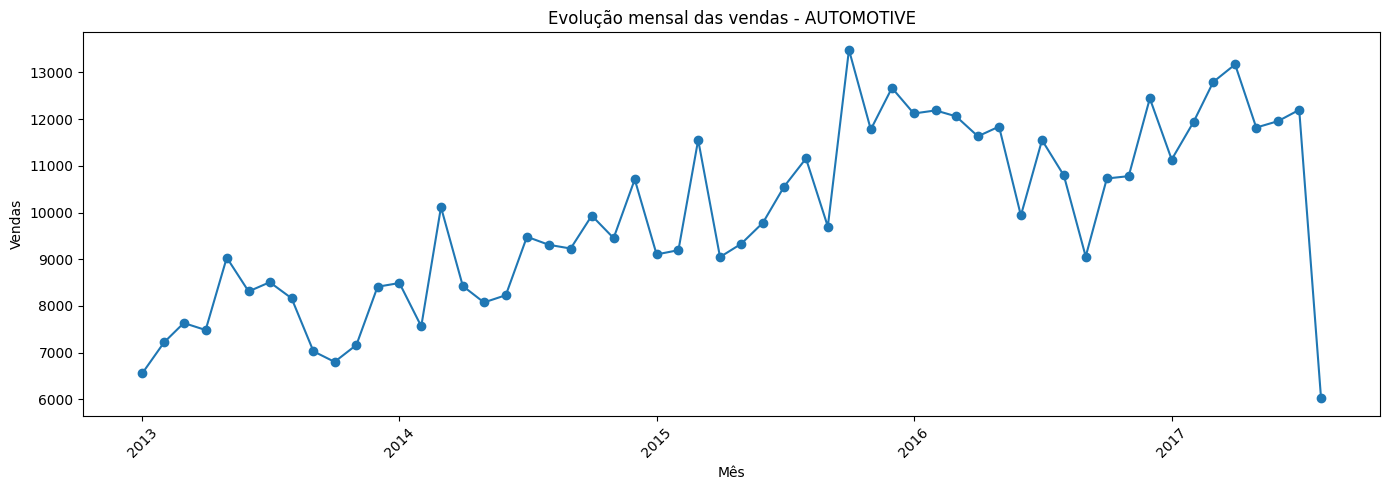

In [11]:
# Visualizando a evolução mensal das vendas de uma família de produto

family_name = "AUTOMOTIVE"

family_monthly_sales = monthly_sales_by_family[
    monthly_sales_by_family["family"] == family_name
].copy()

family_monthly_sales["month"] = family_monthly_sales["month"].dt.to_timestamp()

plt.figure(figsize=(14, 5))
plt.plot(
    family_monthly_sales["month"],
    family_monthly_sales["sales"],
    marker="o",
)

plt.title(f"Evolução mensal das vendas - {family_name}")
plt.xlabel("Mês")
plt.ylabel("Vendas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# Verificando a quantidade de dias disponíveis em cada mês da série

days_per_month = (
    df.assign(month=df["date"].dt.to_period("M"))
    .groupby("month")["date"]
    .nunique()
    .tail(12)
)

days_per_month

month
2016-09    30
2016-10    31
2016-11    30
2016-12    30
2017-01    31
2017-02    28
2017-03    31
2017-04    30
2017-05    31
2017-06    30
2017-07    31
2017-08    15
Freq: M, Name: date, dtype: int64

In [13]:
# Calculando a média diária de vendas por mês para a família AUTOMOTIVE

automotive_daily_monthly = (
    df.loc[df["family"] == "AUTOMOTIVE"]
    .groupby(df["date"].dt.to_period("M"))["sales"]
    .sum()
    .to_frame("monthly_sales")
)

automotive_daily_monthly["days"] = (
    df.loc[df["family"] == "AUTOMOTIVE"]
    .groupby(df["date"].dt.to_period("M"))["date"]
    .nunique()
)

automotive_daily_monthly["daily_avg_sales"] = (
    automotive_daily_monthly["monthly_sales"] / automotive_daily_monthly["days"]
)

automotive_daily_monthly.tail(12)

,monthly_sales,days,daily_avg_sales
date,,,
2016-09,"9,058.00",30,301.93
2016-10,"10,728.00",31,346.06
2016-11,"10,778.00",30,359.27
2016-12,"12,442.00",30,414.73
2017-01,"11,134.00",31,359.16
2017-02,"11,936.00",28,426.29
2017-03,"12,794.00",31,412.71
2017-04,"13,169.00",30,438.97
2017-05,"11,818.00",31,381.23


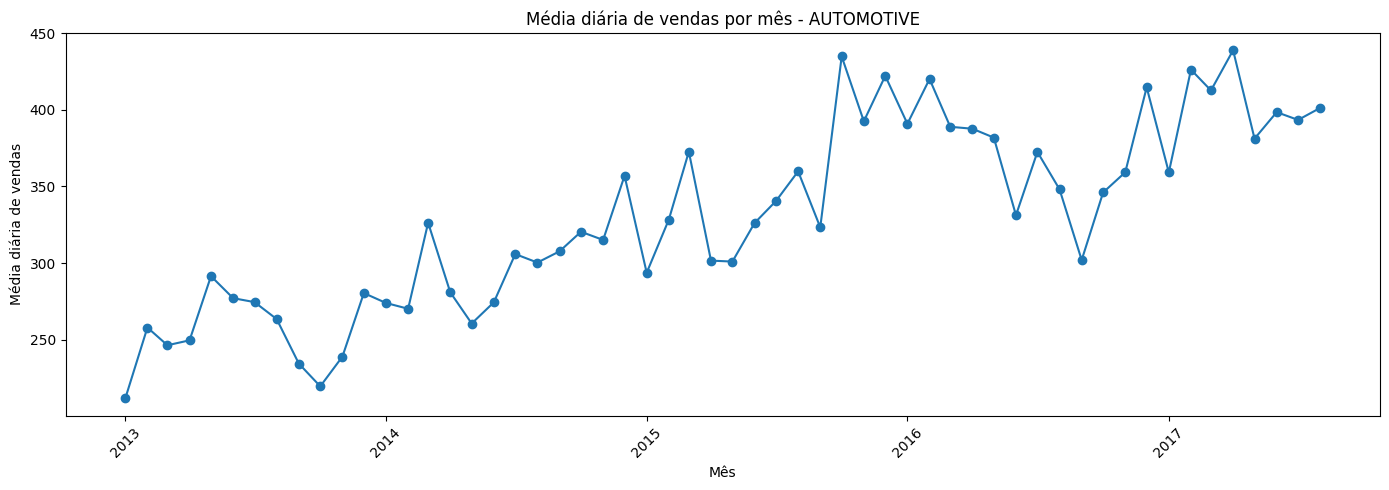

In [14]:
# Visualizando a média diária de vendas por mês para a família AUTOMOTIVE

automotive_daily_monthly = automotive_daily_monthly.reset_index()
automotive_daily_monthly["date"] = automotive_daily_monthly["date"].dt.to_timestamp()

plt.figure(figsize=(14, 5))
plt.plot(
    automotive_daily_monthly["date"],
    automotive_daily_monthly["daily_avg_sales"],
    marker="o",
)

plt.title("Média diária de vendas por mês - AUTOMOTIVE")
plt.xlabel("Mês")
plt.ylabel("Média diária de vendas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# Comparando a média diária de vendas entre os mesmos meses de diferentes anos

automotive_seasonality = automotive_daily_monthly.copy()

automotive_seasonality["year"] = automotive_seasonality["date"].dt.year
automotive_seasonality["month"] = automotive_seasonality["date"].dt.month

seasonality_table = automotive_seasonality.pivot(
    index="year",
    columns="month",
    values="daily_avg_sales",
)

seasonality_table

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2013,211.52,257.86,246.29,249.50,291.42,277.03,274.45,263.35,234.30,219.45,238.87,280.37
2014,273.90,270.11,326.29,280.87,260.48,274.33,305.84,300.29,307.63,320.42,315.07,356.97
2015,293.65,328.36,372.71,301.57,300.94,326.10,340.48,359.87,323.30,434.94,392.57,422.23
2016,390.94,420.17,388.97,387.70,381.90,331.20,372.55,348.13,301.93,346.06,359.27,414.73
2017,359.16,426.29,412.71,438.97,381.23,398.53,393.45,401.33,NaN,NaN,NaN,NaN


In [16]:
# Normalizando a média diária mensal pela média de cada ano

seasonality_normalized = seasonality_table.div(
    seasonality_table.mean(axis=1),
    axis=0,
)

seasonality_normalized.round(2)

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2013,0.83,1.02,0.97,0.98,1.15,1.09,1.08,1.04,0.92,0.87,0.94,1.11
2014,0.91,0.90,1.09,0.94,0.87,0.92,1.02,1.00,1.03,1.07,1.05,1.19
2015,0.84,0.94,1.07,0.86,0.86,0.93,0.97,1.03,0.92,1.24,1.12,1.21
2016,1.06,1.13,1.05,1.05,1.03,0.89,1.01,0.94,0.82,0.93,0.97,1.12
2017,0.89,1.06,1.03,1.09,0.95,0.99,0.98,1.00,NaN,NaN,NaN,NaN


In [17]:
# Calculando o índice sazonal médio por mês com base nos anos completos

complete_years = seasonality_normalized.loc[2013:2016]

seasonal_index = complete_years.mean(axis=0).round(2)

seasonal_index

month
1    0.91
2    1.00
3    1.04
4    0.96
5    0.98
6    0.96
7    1.02
8    1.00
9    0.92
10   1.03
11   1.02
12   1.16
dtype: float64

In [18]:
# Comparando o índice sazonal mensal entre diferentes famílias de produto

selected_families = [
    "AUTOMOTIVE",
    "BEVERAGES",
    "GROCERY I",
    "PRODUCE",
]

family_monthly = (
    df.loc[df["family"].isin(selected_families)]
    .assign(
        year=df["date"].dt.year,
        month=df["date"].dt.month,
    )
    .groupby(["family", "year", "month"], as_index=False)
    .agg(
        monthly_sales=("sales", "sum"),
        days=("date", "nunique"),
    )
)

family_monthly["daily_avg_sales"] = (
    family_monthly["monthly_sales"] / family_monthly["days"]
)

complete_years = family_monthly[family_monthly["year"].between(2013, 2016)].copy()

complete_years["yearly_avg"] = complete_years.groupby(["family", "year"])[
    "daily_avg_sales"
].transform("mean")

complete_years["seasonal_index"] = (
    complete_years["daily_avg_sales"] / complete_years["yearly_avg"]
)

seasonality_by_family = (
    complete_years.groupby(["family", "month"])["seasonal_index"]
    .mean()
    .unstack("month")
    .round(2)
)

seasonality_by_family

month,1,2,3,4,5,6,7,8,9,10,11,12
family,,,,,,,,,,,,
AUTOMOTIVE,0.91,1.00,1.04,0.96,0.98,0.96,1.02,1.00,0.92,1.03,1.02,1.16
BEVERAGES,0.92,0.76,0.94,0.82,0.86,0.93,1.04,0.93,1.17,1.13,1.18,1.31
GROCERY I,0.87,0.91,0.95,1.00,0.98,0.97,0.96,0.98,0.99,1.01,1.05,1.35
PRODUCE,0.67,0.26,0.84,0.51,0.62,1.03,1.36,0.97,1.39,1.32,1.40,1.63


In [19]:
# Identificando o primeiro ano completo de atividade de cada família

first_complete_year = first_sale_by_family.apply(
    lambda date: date.year if date.month == 1 and date.day == 1 else date.year + 1
)

family_activity_start = pd.DataFrame(
    {
        "first_positive_sale": first_sale_by_family,
        "first_complete_year": first_complete_year,
    }
)

family_activity_start.head(15)

,first_positive_sale,first_complete_year
family,,
BOOKS,2016-10-08,2017
BABY CARE,2014-03-01,2015
SCHOOL AND OFFICE SUPPLIES,2014-01-02,2015
LADIESWEAR,2014-01-02,2015
HOME AND KITCHEN II,2014-01-01,2014
PLAYERS AND ELECTRONICS,2014-01-01,2014
CELEBRATION,2014-01-01,2014
PET SUPPLIES,2014-01-01,2014
MAGAZINES,2014-01-01,2014


In [20]:
# Mantendo apenas anos completos de atividade para cada família

family_monthly_valid = family_monthly.merge(
    family_activity_start[["first_complete_year"]],
    left_on="family",
    right_index=True,
    how="left",
)

family_monthly_valid = family_monthly_valid[
    (family_monthly_valid["year"] >= family_monthly_valid["first_complete_year"])
    & (family_monthly_valid["year"] <= 2016)
].copy()

family_monthly_valid[
    ["family", "year", "month", "daily_avg_sales", "first_complete_year"]
].head(20)

,family,year,month,daily_avg_sales,first_complete_year
12,AUTOMOTIVE,2014,1,273.90,2014
13,AUTOMOTIVE,2014,2,270.11,2014
14,AUTOMOTIVE,2014,3,326.29,2014
15,AUTOMOTIVE,2014,4,280.87,2014
16,AUTOMOTIVE,2014,5,260.48,2014
17,AUTOMOTIVE,2014,6,274.33,2014
18,AUTOMOTIVE,2014,7,305.84,2014
19,AUTOMOTIVE,2014,8,300.29,2014
20,AUTOMOTIVE,2014,9,307.63,2014
21,AUTOMOTIVE,2014,10,320.42,2014


In [21]:
# Calculando o índice sazonal com base apenas nos anos completos de cada família

family_monthly_valid["yearly_avg"] = family_monthly_valid.groupby(["family", "year"])[
    "daily_avg_sales"
].transform("mean")

family_monthly_valid["seasonal_index"] = (
    family_monthly_valid["daily_avg_sales"] / family_monthly_valid["yearly_avg"]
)

seasonality_by_family_valid = (
    family_monthly_valid.groupby(["family", "month"])["seasonal_index"]
    .mean()
    .unstack("month")
    .round(2)
)

seasonality_by_family_valid.loc[["AUTOMOTIVE", "BEVERAGES", "GROCERY I", "PRODUCE"]]

month,1,2,3,4,5,6,7,8,9,10,11,12
family,,,,,,,,,,,,
AUTOMOTIVE,0.94,0.99,1.07,0.95,0.92,0.91,1.00,0.99,0.92,1.08,1.05,1.17
BEVERAGES,0.92,0.76,0.94,0.82,0.86,0.93,1.04,0.93,1.17,1.13,1.18,1.31
GROCERY I,0.87,0.91,0.95,1.00,0.98,0.97,0.96,0.98,0.99,1.01,1.05,1.35
PRODUCE,0.90,0.34,0.90,0.33,0.34,0.89,1.41,0.86,1.47,1.45,1.48,1.63


In [22]:
# Verificando a consistência da sazonalidade de PRODUCE entre os anos completos

produce_seasonality = (
    family_monthly_valid[family_monthly_valid["family"] == "PRODUCE"]
    .pivot(
        index="year",
        columns="month",
        values="seasonal_index",
    )
    .round(2)
)

produce_seasonality

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2014,1.63,0.00,1.69,0.00,0.00,0.00,1.62,0.00,1.76,1.70,1.74,1.84
2015,0.00,0.00,0.00,0.00,0.00,1.67,1.65,1.64,1.71,1.66,1.72,1.93
2016,1.06,1.02,1.01,1.00,1.02,0.98,0.96,0.93,0.94,0.98,0.99,1.12


In [23]:
# Verificando a quantidade de lojas com vendas positivas de PRODUCE em cada mês

produce_active_stores = (
    df.loc[(df["family"] == "PRODUCE") & (df["sales"] > 0)]
    .assign(month=df["date"].dt.to_period("M"))
    .groupby("month")["store_nbr"]
    .nunique()
)

produce_active_stores.loc["2014":"2016"]

month
2014-01    47
2014-02    24
2014-03    47
2014-04    24
2014-05    24
2014-06    24
2014-07    48
2014-08    25
2014-09    48
2014-10    48
2014-11    48
2014-12    48
2015-01    25
2015-02    25
2015-03    25
2015-04    25
2015-05    25
2015-06    50
2015-07    51
2015-08    52
2015-09    52
2015-10    53
2015-11    53
2015-12    53
2016-01    53
2016-02    53
2016-03    53
2016-04    53
2016-05    53
2016-06    53
2016-07    53
2016-08    53
2016-09    51
2016-10    52
2016-11    52
2016-12    53
Freq: M, Name: store_nbr, dtype: int64

In [24]:
# Analisando vendas mensais de PRODUCE por loja ativa

produce_monthly = (
    df.loc[df["family"] == "PRODUCE"]
    .assign(month=df["date"].dt.to_period("M"))
    .groupby("month")
    .agg(
        total_sales=("sales", "sum"),
        active_stores=(
            "store_nbr",
            lambda stores: stores[df.loc[stores.index, "sales"] > 0].nunique(),
        ),
    )
)

produce_monthly["sales_per_active_store"] = (
    produce_monthly["total_sales"] / produce_monthly["active_stores"]
)

produce_monthly.loc["2014":"2016"].head(24)

,total_sales,active_stores,sales_per_active_store
month,,,
2014-01,"3,243,616.58",47,"69,013.12"
2014-02,"6,576.00",24,274.00
2014-03,"3,352,346.25",47,"71,326.52"
2014-04,"7,152.00",24,298.00
2014-05,"9,094.00",24,378.92
2014-06,"8,283.00",24,345.12
2014-07,"3,216,023.26",48,"67,000.48"
2014-08,"8,265.00",25,330.60
2014-09,"3,388,714.61",48,"70,598.22"


In [25]:
# Comparando as lojas com vendas positivas de PRODUCE entre janeiro e fevereiro de 2014

produce_2014 = df.loc[(df["family"] == "PRODUCE") & (df["date"].dt.year == 2014)]

january_stores = set(
    produce_2014.loc[
        (produce_2014["date"].dt.month == 1) & (produce_2014["sales"] > 0),
        "store_nbr",
    ]
)

february_stores = set(
    produce_2014.loc[
        (produce_2014["date"].dt.month == 2) & (produce_2014["sales"] > 0),
        "store_nbr",
    ]
)

print("Lojas ativas em janeiro:", len(january_stores))
print("Lojas ativas em fevereiro:", len(february_stores))

print("\nLojas presentes em janeiro e ausentes em fevereiro:")
print(sorted(january_stores - february_stores))

Lojas ativas em janeiro: 47
Lojas ativas em fevereiro: 24

Lojas presentes em janeiro e ausentes em fevereiro:
[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 28, 30, 31, 32, 33, 34, 35, 36, 39, 40, 43, 54]


In [26]:
# Comparando as vendas de janeiro entre lojas que continuaram ou deixaram de vender PRODUCE

january_produce = produce_2014.loc[produce_2014["date"].dt.month == 1].copy()

january_produce["store_group"] = january_produce["store_nbr"].apply(
    lambda store: (
        "Ausente em fevereiro"
        if store in january_stores - february_stores
        else "Presente em fevereiro"
    )
)

sales_by_store_group = (
    january_produce.groupby("store_group")["sales"].sum().sort_values(ascending=False)
)

sales_by_store_group

store_group
Presente em fevereiro   2,723,852.78
Ausente em fevereiro      519,763.81
Name: sales, dtype: float64

In [27]:
# Comparando as vendas de PRODUCE nas mesmas lojas entre janeiro e fevereiro de 2014

common_stores = january_stores & february_stores

produce_common_stores = produce_2014.loc[
    produce_2014["store_nbr"].isin(common_stores)
].copy()

sales_common_stores_by_month = (
    produce_common_stores.assign(month=produce_common_stores["date"].dt.month)
    .groupby("month")["sales"]
    .sum()
    .loc[[1, 2]]
)

sales_common_stores_by_month

month
1   2,723,852.78
2       6,576.00
Name: sales, dtype: float64

In [28]:
# Analisando as vendas diárias de PRODUCE nas lojas ativas em janeiro e fevereiro de 2014

produce_daily_common_stores = produce_common_stores.groupby("date", as_index=False)[
    "sales"
].sum()

produce_daily_common_stores.loc[
    produce_daily_common_stores["date"].between(
        "2014-01-01",
        "2014-03-31",
    )
]

,date,sales
0,2014-01-01,762.64
1,2014-01-02,"113,456.99"
2,2014-01-03,"94,480.98"
3,2014-01-04,"118,226.97"
4,2014-01-05,"127,443.16"
...,...,...
85,2014-03-27,"62,123.43"
86,2014-03-28,"73,882.68"
87,2014-03-29,"104,476.31"
88,2014-03-30,"114,163.97"


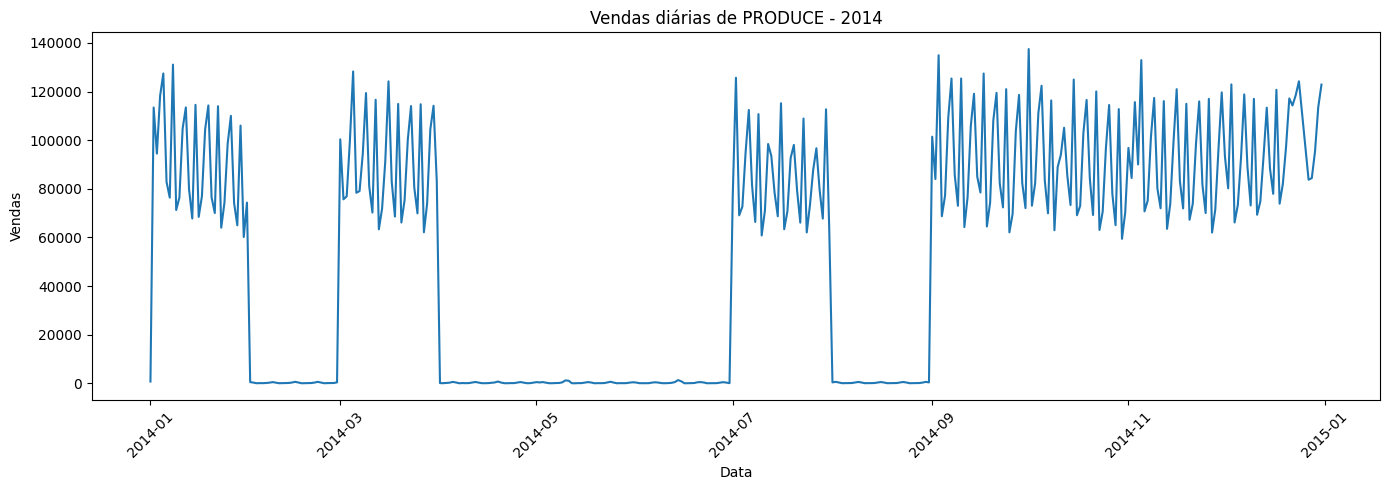

In [29]:
# Visualizando as vendas diárias de PRODUCE em 2014

plt.figure(figsize=(14, 5))

plt.plot(
    produce_daily_common_stores["date"],
    produce_daily_common_stores["sales"],
)

plt.title("Vendas diárias de PRODUCE - 2014")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

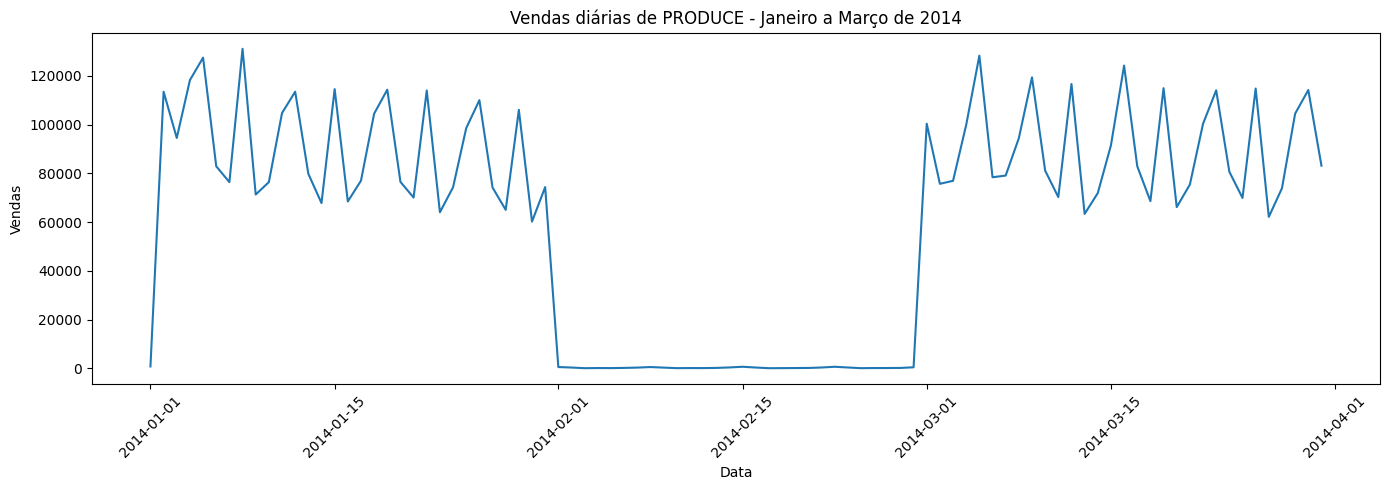

In [30]:
# Filtrando as vendas diárias de PRODUCE entre janeiro e março de 2014

produce_jan_mar = produce_daily_common_stores.loc[
    produce_daily_common_stores["date"].between(
        "2014-01-01",
        "2014-03-31",
    )
].copy()

plt.figure(figsize=(14, 5))

plt.plot(
    produce_jan_mar["date"],
    produce_jan_mar["sales"],
)

plt.title("Vendas diárias de PRODUCE - Janeiro a Março de 2014")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
# Comparando as vendas diárias de PRODUCE em fevereiro entre diferentes anos

produce_february = (
    df.loc[(df["family"] == "PRODUCE") & (df["date"].dt.month == 2)]
    .assign(year=df["date"].dt.year)
    .groupby("year")
    .agg(
        total_sales=("sales", "sum"),
        daily_avg_sales=("sales", "mean"),
    )
)

produce_february

,total_sales,daily_avg_sales
year,,
2013,0.00,0.00
2014,"6,576.00",4.35
2015,"7,907.00",5.23
2016,"3,585,008.59","2,289.28"
2017,"3,571,332.77","2,361.99"


In [32]:
# Analisando a evolução mensal das vendas de PRODUCE ao longo do tempo

produce_monthly_sales = (
    df.loc[df["family"] == "PRODUCE"]
    .assign(month=df["date"].dt.to_period("M"))
    .groupby("month")["sales"]
    .sum()
)

produce_monthly_sales.loc["2014":"2016"]

month
2014-01   3,243,616.58
2014-02       6,576.00
2014-03   3,352,346.25
2014-04       7,152.00
2014-05       9,094.00
2014-06       8,283.00
2014-07   3,216,023.26
2014-08       8,265.00
2014-09   3,388,714.61
2014-10   3,380,437.01
2014-11   3,346,861.56
2014-12   3,545,158.51
2015-01       7,554.00
2015-02       7,907.00
2015-03       6,905.00
2015-04       7,163.00
2015-05      10,172.00
2015-06   3,519,216.54
2015-07   3,583,142.79
2015-08   3,562,251.92
2015-09   3,599,059.59
2015-10   3,615,706.45
2015-11   3,624,200.81
2015-12   4,052,565.44
2016-01   3,980,591.70
2016-02   3,585,008.59
2016-03   3,786,813.37
2016-04   3,621,327.49
2016-05   3,832,996.61
2016-06   3,560,052.79
2016-07   3,609,957.44
2016-08   3,489,905.48
2016-09   3,427,137.61
2016-10   3,673,368.55
2016-11   3,605,235.81
2016-12   4,075,705.02
Freq: M, Name: sales, dtype: float64

In [33]:
# Analisando a transição diária das vendas de PRODUCE entre maio e junho de 2015

produce_may_june_2015 = (
    df.loc[
        (df["family"] == "PRODUCE") & (df["date"].between("2015-05-01", "2015-06-30"))
    ]
    .groupby("date", as_index=False)["sales"]
    .sum()
)

produce_may_june_2015

,date,sales
0,2015-05-01,894.00
1,2015-05-02,697.00
2,2015-05-03,304.00
3,2015-05-04,42.00
4,2015-05-05,51.00
...,...,...
56,2015-06-26,"92,485.59"
57,2015-06-27,"125,449.28"
58,2015-06-28,"147,185.47"
59,2015-06-29,"104,018.24"


In [34]:
# Identificando as maiores variações diárias nas vendas de PRODUCE

produce_may_june_2015["sales_diff"] = produce_may_june_2015["sales"].diff()

produce_may_june_2015.sort_values(
    "sales_diff",
    ascending=False,
).head(10)

,date,sales,sales_diff
31,2015-06-01,"115,242.91","114,940.91"
50,2015-06-20,"148,067.83","45,263.55"
57,2015-06-27,"125,449.28","32,963.69"
33,2015-06-03,"152,806.36","32,438.70"
36,2015-06-06,"129,070.06","31,659.30"
43,2015-06-13,"125,091.87","30,210.12"
47,2015-06-17,"145,428.97","29,830.46"
40,2015-06-10,"137,377.69","29,711.38"
54,2015-06-24,"139,986.15","26,238.04"
37,2015-06-07,"153,590.72","24,520.66"


In [35]:
# Comparando vendas nas mesmas lojas antes e depois da quebra estrutural

comparison_dates = pd.to_datetime(["2015-05-31", "2015-06-01"])

produce_change_point = df.loc[
    (df["family"] == "PRODUCE") & (df["date"].isin(comparison_dates))
].copy()

stores_may_31 = set(
    produce_change_point.loc[
        (produce_change_point["date"] == pd.Timestamp("2015-05-31"))
        & (produce_change_point["sales"] > 0),
        "store_nbr",
    ]
)

stores_june_01 = set(
    produce_change_point.loc[
        (produce_change_point["date"] == pd.Timestamp("2015-06-01"))
        & (produce_change_point["sales"] > 0),
        "store_nbr",
    ]
)

common_stores = stores_may_31 & stores_june_01

sales_common_stores = (
    produce_change_point.loc[produce_change_point["store_nbr"].isin(common_stores)]
    .groupby("date")["sales"]
    .sum()
)

sales_common_stores

date
2015-05-31      302.00
2015-06-01   90,953.61
Name: sales, dtype: float64

In [36]:
# Comparando o volume de vendas por loja antes e depois da quebra estrutural

sales_by_store = produce_change_point.loc[
    produce_change_point["store_nbr"].isin(common_stores)
].pivot(
    index="store_nbr",
    columns="date",
    values="sales",
)

sales_by_store["growth_ratio"] = (
    sales_by_store[pd.Timestamp("2015-06-01")]
    / sales_by_store[pd.Timestamp("2015-05-31")]
)

sales_by_store.sort_values(
    pd.Timestamp("2015-06-01"),
    ascending=False,
).head(20)

date,2015-05-31 00:00:00,2015-06-01 00:00:00,growth_ratio
store_nbr,,,
44,27.00,"10,648.38",394.38
3,23.00,"8,544.76",371.51
49,18.00,"7,796.56",433.14
45,29.00,"7,105.71",245.02
47,15.00,"6,673.32",444.89
7,35.00,"6,208.61",177.39
51,21.00,"4,976.23",236.96
8,4.00,"4,758.11","1,189.53"
24,5.00,"3,634.61",726.92


In [37]:
# Resumindo a mudança de vendas nas lojas presentes nos dois dias

before = pd.Timestamp("2015-05-31")
after = pd.Timestamp("2015-06-01")

sales_by_store["sales_diff"] = sales_by_store[after] - sales_by_store[before]

sales_by_store["growth_ratio"] = sales_by_store[after] / sales_by_store[before]

change_summary = pd.Series(
    {
        "lojas_analisadas": len(sales_by_store),
        "lojas_com_aumento": (sales_by_store["sales_diff"] > 0).sum(),
        "lojas_com_queda": (sales_by_store["sales_diff"] < 0).sum(),
        "lojas_sem_mudanca": (sales_by_store["sales_diff"] == 0).sum(),
        "aumento_mediano_em_vezes": sales_by_store["growth_ratio"].median(),
        "diferenca_mediana_vendas": sales_by_store["sales_diff"].median(),
    }
)

change_summary

lojas_analisadas              24.00
lojas_com_aumento             24.00
lojas_com_queda                0.00
lojas_sem_mudanca              0.00
aumento_mediano_em_vezes     367.71
diferenca_mediana_vendas   2,561.69
dtype: float64

### Quebra estrutural em PRODUCE

A análise temporal identificou uma mudança abrupta no comportamento da família
`PRODUCE` em 01/06/2015.

Entre 31/05/2015 e 01/06/2015:

- as vendas totais passaram de aproximadamente 302 para 115 mil;
- o número de lojas com vendas positivas aumentou de 24 para 50;
- entre as 24 lojas presentes nos dois dias, todas apresentaram aumento de vendas;
- o crescimento mediano entre essas lojas foi de aproximadamente 368 vezes.

Esses resultados indicam uma quebra estrutural na série, e não apenas uma
variação sazonal. A causa da mudança não pode ser determinada apenas com os
dados disponíveis.

In [38]:
# Comparando a mudança de vendas entre todas as famílias na data da quebra

before = pd.Timestamp("2015-05-31")
after = pd.Timestamp("2015-06-01")

family_change = (
    df.loc[df["date"].isin([before, after])]
    .groupby(["family", "date"])["sales"]
    .sum()
    .unstack()
    .rename(
        columns={
            before: "sales_before",
            after: "sales_after",
        }
    )
)

family_change["sales_diff"] = (
    family_change["sales_after"] - family_change["sales_before"]
)

family_change["growth_ratio"] = (
    family_change["sales_after"]
    .div(family_change["sales_before"])
    .where(family_change["sales_before"] > 0)
)

family_change.sort_values(
    "growth_ratio",
    ascending=False,
).head(15)

date,sales_before,sales_after,sales_diff,growth_ratio
family,,,,
PRODUCE,302.00,"115,242.91","114,940.91",381.60
PET SUPPLIES,50.00,317.00,267.00,6.34
HOME APPLIANCES,10.00,16.00,6.00,1.60
HARDWARE,58.00,76.00,18.00,1.31
HOME AND KITCHEN I,"1,384.00","1,265.00",-119.00,0.91
BEAUTY,296.00,268.00,-28.00,0.91
MEATS,"25,234.24","19,476.00","-5,758.24",0.77
PREPARED FOODS,"7,115.88","5,236.99","-1,878.90",0.74
CLEANING,"100,616.00","72,717.00","-27,899.00",0.72


In [39]:
# Comparando PRODUCE entre segundas-feiras próximas à quebra estrutural

mondays = pd.to_datetime(
    [
        "2015-05-11",
        "2015-05-18",
        "2015-05-25",
        "2015-06-01",
        "2015-06-08",
    ]
)

produce_mondays = (
    df.loc[(df["family"] == "PRODUCE") & (df["date"].isin(mondays))]
    .groupby("date")["sales"]
    .sum()
)

produce_mondays

date
2015-05-11        37.00
2015-05-18        54.00
2015-05-25        51.00
2015-06-01   115,242.91
2015-06-08   109,757.56
Name: sales, dtype: float64

Além disso, a comparação entre segundas-feiras mostrou que a mudança não pode
ser explicada apenas por efeito de dia da semana. As vendas de `PRODUCE`
permaneceram na casa das dezenas durante as segundas-feiras de maio e passaram
para mais de 100 mil a partir de 01/06/2015, mantendo esse novo patamar na
semana seguinte.

Isso reforça a evidência de uma mudança persistente de regime na série.

In [40]:
# Analisando o volume diário de vendas por dia da semana

daily_sales = df.groupby("date", as_index=False)["sales"].sum()

daily_sales["day_of_week"] = daily_sales["date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_sales = (
    daily_sales.groupby("day_of_week")["sales"]
    .agg(["mean", "median", "std", "count"])
    .reindex(weekday_order)
)

weekday_sales

,mean,median,std,count
day_of_week,,,,
Monday,"617,542.71","651,800.51","202,901.45",241
Tuesday,"569,926.09","602,440.10","199,672.00",242
Wednesday,"593,244.55","632,951.68","206,976.01",240
Thursday,"505,269.20","531,402.20","168,677.99",240
Friday,"579,574.36","616,645.01","191,907.91",240
Saturday,"772,205.59","816,064.64","221,747.54",241
Sunday,"825,218.12","862,268.40","257,472.92",240


In [41]:
# Comparando as vendas de cada dia da semana com a média geral

overall_daily_mean = daily_sales["sales"].mean()

weekday_sales["difference_pct"] = (
    (weekday_sales["mean"] / overall_daily_mean) - 1
) * 100

weekday_sales[["mean", "difference_pct"]]

,mean,difference_pct
day_of_week,,
Monday,"617,542.71",-3.14
Tuesday,"569,926.09",-10.61
Wednesday,"593,244.55",-6.95
Thursday,"505,269.20",-20.75
Friday,"579,574.36",-9.09
Saturday,"772,205.59",21.12
Sunday,"825,218.12",29.43


### Sazonalidade semanal

As vendas apresentam um padrão semanal claro. Em relação ao volume diário médio,
os domingos apresentam vendas aproximadamente 29% maiores e os sábados cerca
de 21% maiores.

Entre os dias úteis, quinta-feira apresenta o menor volume médio, cerca de 21%
abaixo da média geral.

Esse comportamento indica que o dia da semana pode ser uma variável relevante
para os modelos de previsão de demanda.

In [42]:
# Verificando a consistência da sazonalidade semanal ao longo dos anos

daily_sales["year"] = daily_sales["date"].dt.year

weekday_by_year = (
    daily_sales.groupby(["year", "day_of_week"])["sales"]
    .mean()
    .unstack()
    .reindex(columns=weekday_order)
)

weekday_by_year

day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
year,,,,,,,
2013,"376,433.56","331,873.70","342,623.48","309,327.31","347,734.56","483,799.51","508,780.27"
2014,"561,423.51","518,634.66","529,628.70","456,010.30","507,978.52","700,011.52","753,247.95"
2015,"633,978.32","594,721.48","620,535.35","525,293.55","597,275.12","797,749.73","864,140.33"
2016,"764,078.63","711,337.17","742,917.90","626,385.77","725,051.07","940,911.69","1,028,099.69"
2017,"829,098.94","771,174.39","810,468.92","672,201.40","803,500.88","1,037,252.16","1,062,378.81"


In [43]:
# Normalizando a sazonalidade semanal pela média de cada ano

annual_daily_mean = daily_sales.groupby("year")["sales"].mean()

weekday_by_year_pct = (
    weekday_by_year.div(annual_daily_mean, axis=0).sub(1).mul(100).round(2)
)

weekday_by_year_pct

day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
year,,,,,,,
2013,-2.42,-13.97,-11.18,-19.81,-9.86,25.41,31.89
2014,-2.44,-9.88,-7.97,-20.76,-11.73,21.64,30.89
2015,-4.20,-10.13,-6.23,-20.62,-9.74,20.55,30.58
2016,-3.38,-10.05,-6.06,-20.79,-8.32,18.98,30.00
2017,-3.10,-9.87,-5.27,-21.43,-6.09,21.23,24.17


### Consistência da sazonalidade semanal

A normalização das vendas pela média diária de cada ano mostrou que o padrão
semanal permanece consistente ao longo do período analisado, mesmo com o
crescimento do volume total de vendas.

Quinta-feira apresenta sistematicamente o menor volume, cerca de 20% abaixo
da média anual, enquanto sábado e domingo apresentam os maiores volumes.
Entre 2013 e 2016, os domingos ficaram aproximadamente 30% acima da média
diária de seus respectivos anos.

Isso reforça a presença de uma sazonalidade semanal persistente e justifica
a utilização do dia da semana como variável preditiva no modelo.

In [44]:
# Comparando a sazonalidade semanal entre diferentes famílias

selected_families = [
    "AUTOMOTIVE",
    "BEVERAGES",
    "GROCERY I",
    "CLEANING",
]

family_daily_sales = (
    df.loc[
        (df["family"].isin(selected_families))
        & (df["date"].dt.year.between(2014, 2016))
    ]
    .groupby(["date", "family"], as_index=False)["sales"]
    .sum()
)

family_daily_sales["year"] = family_daily_sales["date"].dt.year
family_daily_sales["day_of_week"] = family_daily_sales["date"].dt.day_name()

family_daily_sales["annual_mean"] = family_daily_sales.groupby(["family", "year"])[
    "sales"
].transform("mean")

family_daily_sales["difference_pct"] = (
    (family_daily_sales["sales"] / family_daily_sales["annual_mean"]) - 1
) * 100

weekday_by_family = (
    family_daily_sales.groupby(["family", "day_of_week"])["difference_pct"]
    .mean()
    .unstack()
    .reindex(columns=weekday_order)
    .round(2)
)

weekday_by_family

day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
family,,,,,,,
AUTOMOTIVE,-10.16,-13.07,-14.34,-19.11,-13.28,30.45,39.66
BEVERAGES,-3.84,-12.92,-12.95,-22.77,-11.61,24.75,39.52
CLEANING,-1.48,-8.57,-9.59,-19.60,-11.85,22.41,28.78
GROCERY I,-0.78,-8.86,-10.16,-19.48,-12.22,20.43,31.19


### Sazonalidade semanal por família

A análise por categoria mostrou que o padrão semanal é consistente entre
diferentes famílias de produtos, com menores volumes durante os dias úteis,
especialmente às quintas-feiras, e maiores volumes aos finais de semana.

Entretanto, a intensidade desse efeito varia entre as famílias. Por exemplo,
`AUTOMOTIVE` apresentou vendas aproximadamente 40% acima de sua média aos
domingos, enquanto `CLEANING` apresentou aumento de cerca de 29%.

Isso indica que o efeito do dia da semana não é uniforme entre as categorias
e sugere uma interação entre a família do produto e a sazonalidade semanal.